In [1]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Embedding, LSTM, BatchNormalization, GRU, Input, Flatten, Dropout, Activation, Conv1D, MaxPooling1D, AveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Model evaluation
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

import keras
from keras.preprocessing import sequence
from keras.preprocessing.sequence import pad_sequences

In [2]:
SEED = 42

In [3]:
data_folder = 'datasets_combined_augmented'

# Paths to your previously saved files
X_train = np.load(f'../{data_folder}/X_deep_train.npy', mmap_mode='r')
y_train = np.load(f'../{data_folder}/y_deep_train.npy')
X_val = np.load(f'../{data_folder}/X_deep_val.npy')
y_val = np.load(f'../{data_folder}/y_deep_val.npy')
X_test = np.load(f'../{data_folder}/X_deep_test.npy')
y_test = np.load(f'../{data_folder}/y_deep_test.npy')

In [4]:
# Suppose y_train, y_val, y_test are like [1, 2, 3, 4, 5, 6, 7, 8]
# Convert them to zero-based index labels (required for to_categorical)
y_train_enc = y_train - 1
y_val_enc = y_val - 1
y_test_enc = y_test - 1

# Get number of classes automatically
num_classes = np.max(y_train_enc) + 1

# Convert to one-hot (instead of labels being a single integer, converts it to a binary vector)
# e.g. if happy = 2, it will be represented like this -> [0,1,0,0,0,0,0,0]
y_train_cat = to_categorical(y_train_enc, num_classes)
y_val_cat = to_categorical(y_val_enc, num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes)

# --- Get shape info for the model ---
time_steps = X_train.shape[1]
num_features = X_train.shape[2]

print(f"Time steps: {time_steps}, Num features: {num_features}, Classes: {num_classes}")

Time steps: 483, Num features: 92, Classes: 7


In [5]:
# --- Normalize features ---
# compute mean and sd from the train data
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

# standardize
X_train = (X_train - mean) / (std)
X_val = (X_val - mean) / (std)
X_test = (X_test - mean) / (std)

In [6]:
classes, counts = np.unique(y_train, return_counts=True)
print(dict(zip(classes, counts)))

{np.int64(1): np.int64(3892), np.int64(2): np.int64(4052), np.int64(3): np.int64(4044), np.int64(4): np.int64(4052), np.int64(5): np.int64(4048), np.int64(6): np.int64(4052), np.int64(7): np.int64(1420)}


In [7]:
MAX_TIME_STEPS = 500  # pick based on your dataset
X_train = pad_sequences(X_train, maxlen=MAX_TIME_STEPS, padding='post', truncating='post')
X_val   = pad_sequences(X_val,   maxlen=MAX_TIME_STEPS, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=MAX_TIME_STEPS, padding='post', truncating='post')

# Combine training and validation sets for cross-validation
X_train_full = np.concatenate([X_train, X_val], axis=0)
y_train_full = np.concatenate([y_train, y_val], axis=0)

In [8]:
# use StratifiedKFold to maintain class ratios per fold
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [9]:
import tensorflow as tf
from tensorflow.keras import layers as L

# function to re-initialize a fresh CNN–BiLSTM model for each fold.
def create_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        L.Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=input_shape),
        L.BatchNormalization(),
        L.MaxPool1D(pool_size=2, strides=2, padding='same'),

        L.Conv1D(128, kernel_size=3, strides=1, padding='same', activation='relu'),
        L.BatchNormalization(),
        L.MaxPool1D(pool_size=2, strides=2, padding='same'),
        L.Dropout(0.2),

        L.Conv1D(256, kernel_size=3, strides=1, padding='same', activation='relu'),
        L.BatchNormalization(),
        L.MaxPool1D(pool_size=2, strides=2, padding='same'),
        L.Dropout(0.2),

        L.Bidirectional(L.LSTM(128, return_sequences=False)),
        L.Dropout(0.3),

        L.Dense(256, activation='relu'),
        L.Dropout(0.3),
        L.Dense(128, activation='relu'),

        L.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [10]:
# Loop to perform 5 fold CV
from sklearn.utils.class_weight import compute_class_weight

val_accuracies = []
fold = 1
histories = []

for train_idx, val_idx in skf.split(X_train_full, y_train_full):
    callbacks = [
        EarlyStopping(
            patience=10,                # stop if val_loss doesn't improve for 10 epochs
            restore_best_weights=True   # revert to best model
        ),
        ModelCheckpoint(
            'best_lstm_model_kfold_aug_data.keras',    # file to save the best model
            save_best_only=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6
        )
    ]

    print(f"\n🟦 Fold {fold} ---------------------------")

    X_tr, X_val_cv = X_train_full[train_idx], X_train_full[val_idx]
    y_tr, y_val_cv = y_train_full[train_idx], y_train_full[val_idx]

    # One-hot encode labels
    y_tr_cat = to_categorical(y_tr - 1, num_classes)
    y_val_cat = to_categorical(y_val_cv - 1, num_classes)

    # Compute class weights for this fold
    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    class_weights = dict(enumerate(cw))

    # Build and train model
    model_fold = create_model((X_tr.shape[1], X_tr.shape[2]), num_classes)

    history = model_fold.fit(
        X_tr, y_tr_cat,
        validation_data=(X_val_cv, y_val_cat),
        epochs=50,
        batch_size=64,
        verbose=1,
        callbacks=callbacks,
        class_weight=class_weights
    )

    # Record best validation accuracy for this fold
    best_val_acc = max(history.history['val_accuracy'])
    val_accuracies.append(best_val_acc)
    print(f"✅ Fold {fold} best val acc: {best_val_acc:.3f}")
    
    histories.append(history)

    fold += 1

print("\n=====================================")
print(f"Mean validation accuracy: {np.mean(val_accuracies):.3f} ± {np.std(val_accuracies):.3f}")
print("=====================================")



🟦 Fold 1 ---------------------------


c:\AowenC\School\Y4 S1\MH4510\Project\Statistical-Learning-and-Data-Mining\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
426/426 ━━━━━━━━━━━━━━━━━━━━ 167s 370ms/step - accuracy: 0.4564 - loss: 1.2607 - val_accuracy: 0.5508 - val_loss: 1.1609 - learning_rate: 0.0010
Epoch 2/25
426/426 ━━━━━━━━━━━━━━━━━━━━ 154s 361ms/step - accuracy: 0.5916 - loss: 0.9787 - val_accuracy: 0.6102 - val_loss: 1.0047 - learning_rate: 0.0010
Epoch 3/25
426/426 ━━━━━━━━━━━━━━━━━━━━ 152s 356ms/step - accuracy: 0.6385 - loss: 0.8789 - val_accuracy: 0.6620 - val_loss: 0.8991 - learning_rate: 0.0010
Epoch 4/25
426/426 ━━━━━━━━━━━━━━━━━━━━ 152s 358ms/step - accuracy: 0.6771 - loss: 0.7892 - val_accuracy: 0.6987 - val_loss: 0.7961 - learning_rate: 0.0010
Epoch 5/25
426/426 ━━━━━━━━━━━━━━━━━━━━ 150s 353ms/step - accuracy: 0.7105 - loss: 0.7147 - val_accuracy: 0.7163 - val_loss: 0.7617 - learning_rate: 0.0010
Epoch 6/25
426/426 ━━━━━━━━━━━━━━━━━━━━ 149s 350ms/step - accuracy: 0.7381 - loss: 0.6483 - val_accuracy: 0.7377 - val_loss: 0.6957 - learning_rate: 0.0010
Epoch 7/25
426/426 ━━━━━━━━━━━━━━━━━━━━ 152s 356ms/step - accura

In [ ]:
# callbacks = [
#     EarlyStopping(
#         patience=10,                # stop if val_loss doesn't improve for 10 epochs
#         restore_best_weights=True   # revert to best model
#     ),
#     ModelCheckpoint(
#         'best_lstm_model_kfold_aug_data.keras',    # file to save the best model
#         save_best_only=True
#     ),
#     ReduceLROnPlateau(
#         monitor='val_loss',
#         factor=0.5,
#         patience=5,
#         min_lr=1e-6
#     )
# ]

# # from sklearn.utils.class_weight import compute_class_weight
# # cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# # class_weights = dict(enumerate(cw))

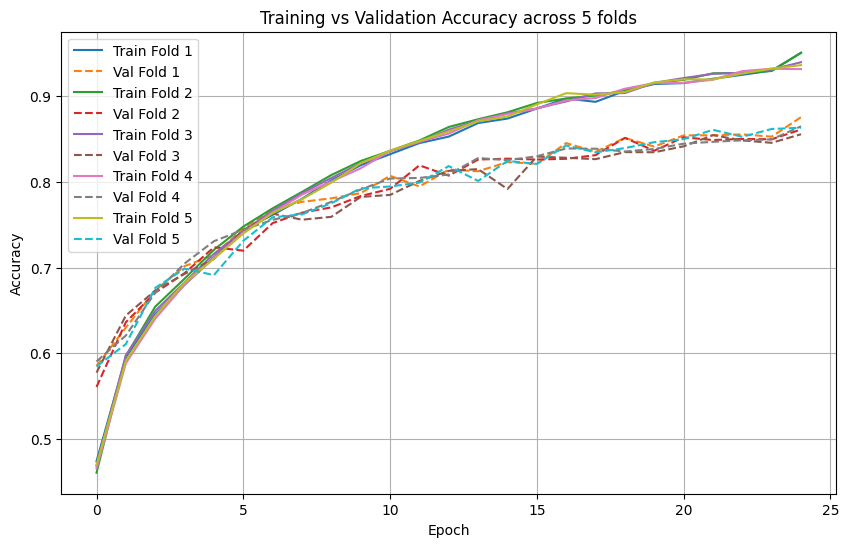

In [ ]:
plt.figure(figsize=(10,6))

for i, history in enumerate(histories, 1):
    plt.plot(history.history['accuracy'], label=f'Train Fold {i}')
    plt.plot(history.history['val_accuracy'], linestyle='--', label=f'Val Fold {i}')

plt.title('Training vs Validation Accuracy across 5 folds')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

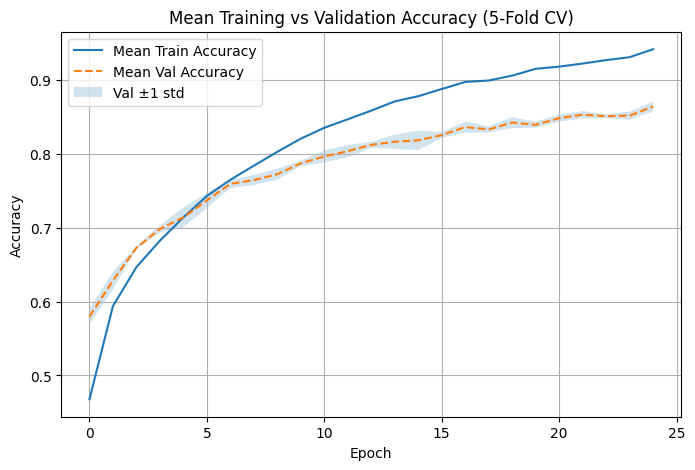

In [ ]:
# pad shorter histories (if early stopping triggered early)
max_epochs = max(len(h.history['accuracy']) for h in histories)
val_accs = np.zeros((len(histories), max_epochs))
train_accs = np.zeros((len(histories), max_epochs))

for i, h in enumerate(histories):
    val_len = len(h.history['val_accuracy'])
    train_accs[i, :val_len] = h.history['accuracy']
    val_accs[i, :val_len] = h.history['val_accuracy']

mean_train = np.mean(train_accs, axis=0)
mean_val = np.mean(val_accs, axis=0)

plt.figure(figsize=(8,5))
plt.plot(mean_train, label='Mean Train Accuracy')
plt.plot(mean_val, label='Mean Val Accuracy', linestyle='--')
plt.fill_between(range(max_epochs),
                 mean_val - np.std(val_accs, axis=0),
                 mean_val + np.std(val_accs, axis=0),
                 alpha=0.2, label='Val ±1 std')

plt.title('Mean Training vs Validation Accuracy (5-Fold CV)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
mean_train = np.mean(train_accs, axis=0)
mean_train

array([0.46788439, 0.59391137, 0.64663292, 0.6824237 , 0.71394513,
       0.74282571, 0.76480341, 0.78386151, 0.80261884, 0.82042989,
       0.83515259, 0.84663292, 0.85839201, 0.87086269, 0.87785358,
       0.88759537, 0.89713175, 0.89911972, 0.90570714, 0.91492077,
       0.91784772, 0.92205106, 0.92670187, 0.93061179, 0.9414246 ])

### Evaluate model

In [ ]:
from tensorflow.keras.models import load_model

# Load model
best_model = load_model('../best_cnn_lstm.keras')

In [ ]:
# Evaluate model on test
test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=1)
print(f"Test Accuracy: {test_acc:.3f}, Test Loss: {test_loss:.3f}")

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "conv1d_6" is incompatible with the layer: expected axis -1 of input shape to have value 128, but received input with shape (None, 543, 92)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 543, 92), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred_classes))


267/267 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step
              precision    recall  f1-score   support

           0       0.69      0.81      0.74      1296
           1       0.57      0.70      0.63      1352
           2       0.72      0.62      0.67      1348
           3       0.72      0.83      0.77      1352
           4       0.66      0.61      0.64      1352
           5       0.76      0.47      0.58      1348
           6       0.86      0.95      0.90       472

    accuracy                           0.69      8520
   macro avg       0.71      0.71      0.70      8520
weighted avg       0.70      0.69      0.68      8520

